In [1]:
# Importing Source Files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
# Data Loading

Dataset = pd.read_csv('C://Users//Aakash//Downloads//Star Classification//Dataset.csv')

In [3]:
Column_Explained = '''
- Object_ID = Feature obj_ID gives the unique identifier for the observation.
- Alpha = Feature 'Alpha' gives the right ascension angle from the measured point. Since it is an angle it will range between 0-360.
- Delta = Feature 'Delta' gives the declination angle from the measured point. Since it is an angle it will range between 0-360.
- U = Feature 'U' is Ultraviolet filter in the photometric system.
- G = Feature 'G' is Green filter in the photometric system.
- R = Feature 'R' is Red filter in the photometric system.
- I = Feature 'I' is Near Infrared filter in the photometric system
- Z = Feature 'Z' is Infrared filter in the photometric system.
- Run_ID = Feature 'Run_ID' is Run Number used to identify the specific scan.
- Rerun_ID = Feature 'Rerun_ID' is Rerun Number to specify how the image was processed
- CamCol_ID = Feature 'CamCol_ID' is Camera column to identify the scanline within the run.
- Field_ID = Feature 'Field_ID' is Field number to identify each field.
- SpecObj_ID = Feature 'SpecObj_ID' is Unique ID used for optical spectroscopic objects.
- Target = Feature 'Target' gives the classification whether spectral data is from a Star, Galaxy, or 
- Redshift = Feature 'Redshift' is redshift value based on the increase in wavelength.
- Plate = Feature 'Plate' is plate ID, identifies each plate in SDSS.
- MJD = Feature 'MJD' is Modified Julian Date, used to indicate when a given piece of SDSS data was taken
- Fiber_ID = Feature 'Fiber_ID' is fiber ID that identifies the fiber that pointed the light at the focal plane in each observation
'''

# Data Preprocessing

In [4]:
print("Dataset Shape :", Dataset.shape)
print(Dataset.shape[1], "Columns and", Dataset.shape[0], "Entries")
print("\nColumns =", list(Dataset.columns))

Dataset Shape : (100000, 18)
18 Columns and 100000 Entries

Columns = ['Object_ID', 'Alpha', 'Delta', 'U', 'G', 'R', 'I', 'Z', 'Run_ID', 'Rerun_ID', 'CamCol_ID', 'Field_ID', 'SpecObj_ID', 'Target', 'Redshift', 'Plate', 'MJD', 'Fiber_ID']


In [5]:
print(Column_Explained)


- Object_ID = Feature obj_ID gives the unique identifier for the observation.
- Alpha = Feature 'Alpha' gives the right ascension angle from the measured point. Since it is an angle it will range between 0-360.
- Delta = Feature 'Delta' gives the declination angle from the measured point. Since it is an angle it will range between 0-360.
- U = Feature 'U' is Ultraviolet filter in the photometric system.
- G = Feature 'G' is Green filter in the photometric system.
- R = Feature 'R' is Red filter in the photometric system.
- I = Feature 'I' is Near Infrared filter in the photometric system
- Z = Feature 'Z' is Infrared filter in the photometric system.
- Run_ID = Feature 'Run_ID' is Run Number used to identify the specific scan.
- Rerun_ID = Feature 'Rerun_ID' is Rerun Number to specify how the image was processed
- CamCol_ID = Feature 'CamCol_ID' is Camera column to identify the scanline within the run.
- Field_ID = Feature 'Field_ID' is Field number to identify each field.
- SpecObj_I

In [6]:
DF = pd.DataFrame()
DF['Count'] = Dataset.count()
DF['Null Count'] = Dataset.isna().sum()
DF['Min'] = Dataset.min()
DF['Max'] = Dataset.max()
DF['Unique'] = Dataset.nunique()
DF['Mean'] = Dataset.mean()
DF['Median'] = Dataset.median()
DF['Standard Deviation'] = Dataset.std()
DF['Variance'] = Dataset.var()
DF['DataType'] = Dataset.dtypes

DF

,Count,Null Count,Min,Max,Unique,Mean,Median,Standard Deviation,Variance,DataType
Object_ID,100000,0,1.23765e+18,1.23768e+18,77734,1.237665e+18,1.237663e+18,8.438560e+12,7.120929e+25,float64
Alpha,100000,0,0.00552783,360,99999,1.776291e+02,1.809007e+02,9.650224e+01,9.312682e+03,float64
Delta,100000,0,-18.7853,83.0005,99999,2.413530e+01,2.364592e+01,1.964467e+01,3.859129e+02,float64
U,100000,0,-9999,32.7814,93748,2.198047e+01,2.217913e+01,3.176929e+01,1.009288e+03,float64
G,100000,0,-9999,31.6022,92651,2.053139e+01,2.109983e+01,3.175029e+01,1.008081e+03,float64
R,100000,0,9.82207,29.5719,91901,1.964576e+01,2.012529e+01,1.854760e+00,3.440134e+00,float64
I,100000,0,9.4699,32.1415,92019,1.908485e+01,1.940514e+01,1.757895e+00,3.090194e+00,float64
Z,100000,0,-9999,29.3837,92007,1.866881e+01,1.900460e+01,3.172815e+01,1.006676e+03,float64
Run_ID,100000,0,109,8162,430,4.481366e+03,4.188000e+03,1.964765e+03,3.860300e+06,int64
Rerun_ID,100000,0,301,301,1,3.010000e+02,3.010000e+02,0.000000e+00,0.000000e+00,int64


# Data Manipulation

In [7]:
Dataset.drop(columns=['Object_ID', 'Run_ID', 'Rerun_ID', 'CamCol_ID', 'Field_ID', 'Fiber_ID'], inplace=True)
Dataset.drop(columns=['MJD'], inplace=True)

Dataset

,Alpha,Delta,U,G,R,I,Z,SpecObj_ID,Target,Redshift,Plate
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,6.543777e+18,GALAXY,0.634794,5812
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,1.176014e+19,GALAXY,0.779136,10445
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,5.152200e+18,GALAXY,0.644195,4576
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,1.030107e+19,GALAXY,0.932346,9149
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,6.891865e+18,GALAXY,0.116123,6121
...,...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,1.055431e+19,GALAXY,0.000000,9374
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,8.586351e+18,GALAXY,0.404895,7626
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,3.112008e+18,GALAXY,0.143366,2764
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,7.601080e+18,GALAXY,0.455040,6751


In [8]:
Incorrect = list(Dataset[Dataset["Alpha"] < 0].index) + list(Dataset[Dataset["Alpha"] > 360].index)
len(Incorrect)

0

In [9]:
Incorrect = list(Dataset[Dataset["Delta"] < 0].index) + list(Dataset[Dataset["Delta"] > 360].index)
len(Incorrect)

12061

In [10]:
Dataset.drop(Incorrect, inplace=True)
Dataset.shape

(87939, 11)

# Feature Selection

In [11]:
Y = Dataset.loc[:,'Target'].values
X = Dataset.drop(columns=['Target'])

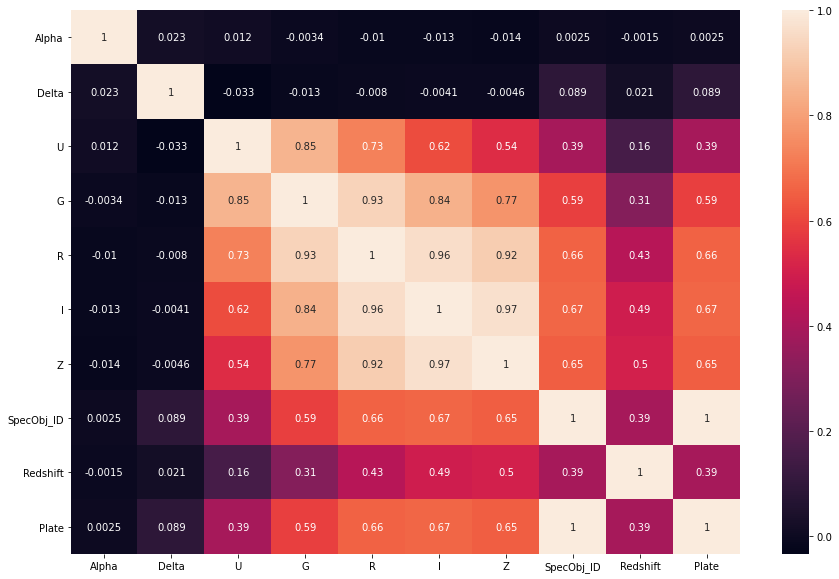

In [12]:
fig = plt.figure(figsize=(15, 10))

sns.heatmap(X.corr(), annot=True)
plt.show()

In [13]:
X.drop(columns=['Plate', 'I', 'G'], inplace=True)

X

,Alpha,Delta,U,R,Z,SpecObj_ID,Redshift
0,135.689107,32.494632,23.87882,20.39501,18.79371,6.543777e+18,0.634794
1,144.826101,31.274185,24.77759,22.58444,21.61427,1.176014e+19,0.779136
2,142.188790,35.582444,25.26307,20.60976,18.94827,5.152200e+18,0.644195
4,345.282593,21.183866,19.43718,16.49747,15.54461,6.891865e+18,0.116123
5,340.995121,20.589476,23.48827,21.32195,19.54544,5.658977e+18,1.424659
...,...,...,...,...,...,...,...
99992,129.862762,14.574312,25.82234,21.43137,19.66464,5.066775e+18,0.587944
99996,29.493819,19.798874,22.69118,20.45003,19.41526,8.586351e+18,0.404895
99997,224.587407,15.700707,21.16916,18.20428,17.35221,3.112008e+18,0.143366
99998,212.268621,46.660365,25.35039,19.91386,18.62482,7.601080e+18,0.455040


<BarContainer object of 3 artists>

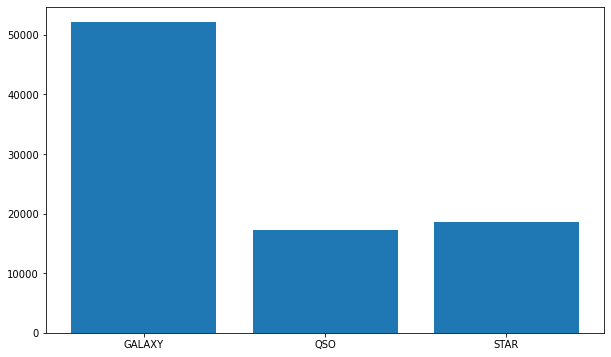

In [14]:
from collections import Counter

count = Counter(Y)
fig = plt.figure(figsize=(10, 6))
plt.bar(count.keys(), count.values())

In [15]:
from imblearn.under_sampling import RandomUnderSampler

Usampler = RandomUnderSampler(sampling_strategy='majority')

X, Y = Usampler.fit_resample(X, Y)
#X, Y = Usampler.fit_resample(X, Y)

<BarContainer object of 3 artists>

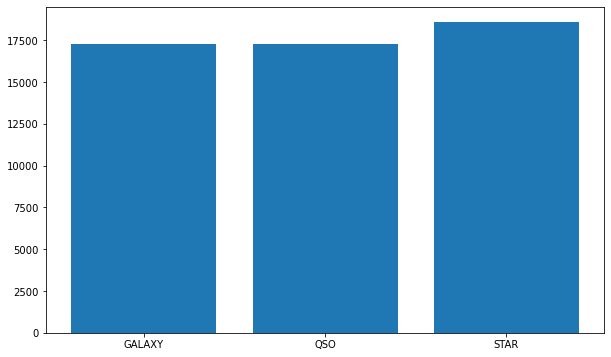

In [16]:
from collections import Counter

count = Counter(Y)
fig = plt.figure(figsize=(10, 6))
plt.bar(count.keys(), count.values())

# Data Splitting

In [17]:
from sklearn.preprocessing import LabelEncoder

LabelEncoder = LabelEncoder()
Y = LabelEncoder.fit_transform(Y)
Y

array([0, 0, 0, ..., 2, 2, 2])

In [18]:
from sklearn.model_selection import train_test_split

XTrain, XTest, YTrain, YTest = train_test_split(X, Y, train_size=0.60, test_size=0.40, random_state=42)
XTest, XValid, YTest, YValid = train_test_split(XTest, YTest, train_size=0.5, test_size=0.5, random_state=42)

In [19]:
print(f"XTrain : {XTrain.shape}, YTrain : {YTrain.shape}")
print(f"XTest : {XTest.shape}, YTest : {YTest.shape}")
print(f"XValid : {XValid.shape}, YValid : {YValid.shape}")

XTrain : (31842, 7), YTrain : (31842,)
XTest : (10614, 7), YTest : (10614,)
XValid : (10614, 7), YValid : (10614,)


# Standardization

In [20]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()

Scaler.fit(XTrain)
_XTrain = Scaler.transform(XTrain)

Scaler.fit(XTest)
_XTest = Scaler.transform(XTest)

Scaler.fit(XValid)
_XValid = Scaler.transform(XValid)

# Model Building

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

AIModel = {
    'K-Neighbors Classifier': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Random Forest Classifier': RandomForestClassifier()
}

for Model in AIModel.values():
    Model.fit(_XTrain, YTrain)

In [22]:
for Name, Model in AIModel.items():
     print(f"Accuracy for {Name} is : ", round(Model.score(_XTest, YTest), 4), "%\n")

Accuracy for K-Neighbors Classifier is :  0.9349 %

Accuracy for Support Vector Machine is :  0.9572 %

Accuracy for Random Forest Classifier is :  0.969 %



# Model Evaluation

In [23]:
from sklearn.model_selection import cross_val_score

for Name, Model in AIModel.items():
    print(f"Report for : {Name}")
    
    Validation = cross_val_score(Model, XValid, YValid)
    print("%0.2f Accuracy with a standard deviation of %0.2f" % (Validation.mean()*100, Validation.std()))
    print()

Report for : K-Neighbors Classifier
56.70 Accuracy with a standard deviation of 0.00

Report for : Support Vector Machine
51.85 Accuracy with a standard deviation of 0.01

Report for : Random Forest Classifier
97.14 Accuracy with a standard deviation of 0.00

